# 02 — Customer Segmentation: RFM Validation + K-Means

**Goal:** Take the rules-based RFM segmentation built in Power BI and validate it with unsupervised K-Means clustering on the same underlying RFM features. Then quantify how much the two approaches agree.

**Why both approaches:**
- **RFM (rules-based):** business-defined quintile scoring, easy to explain to stakeholders, but the segment boundaries are imposed by the analyst.
- **K-Means (unsupervised):** lets the data reveal natural clusters, but the clusters need to be profiled and named after the fact.

If K-Means independently rediscovers the same segments as the RFM rules, the rules are statistically defensible. If K-Means finds segments the rules missed, that's a real discovery worth acting on.

**This notebook does:**
1. Reproduce R, F, M in Python from `fact_sales` and confirm it matches the Power BI values exactly
2. Build K-Means clustering on log-scaled R, F, M features
3. Choose optimal `k` using elbow method and silhouette score
4. Profile each K-Means cluster and assign human-readable names
5. Cross-tabulate Power BI segments vs K-Means clusters
6. Compute Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) — formal agreement metrics
7. Visualize R/F/M in 3D, colored two ways
8. Investigate disagreements between the two approaches
9. Conclude with a recommendation

**Inputs:**
- `data/processed/fact_sales.csv`
- `data/processed/customer_rfm.csv`

**Outputs:**
- `data/predictions/segments.csv` — both Power BI and K-Means segments per customer, ready for the prescriptive notebook
- `models/kmeans_segmentation.joblib` — trained model (for the FastAPI service in Phase 4)


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

DATA_DIR = Path('../data/processed')
PRED_DIR = Path('../data/predictions')
MODELS_DIR = Path('../models')
PRED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print(f'Data dir:        {DATA_DIR.resolve()}')
print(f'Predictions dir: {PRED_DIR.resolve()}')
print(f'Models dir:      {MODELS_DIR.resolve()}')


Data dir:        /home/claude/phase3/data/processed
Predictions dir: /home/claude/phase3/data/predictions
Models dir:      /home/claude/phase3/models


## 2. Reproduce R, F, M in Python from `fact_sales`

First verification step: can we compute the same R, F, M values that Power BI produced? If yes, we have confidence the segmentation logic is reproducible.

**Definitions used (matching Power BI):**
- **Recency** = days between the customer's last order and `max(order_date)` in the dataset.
- **Frequency** = number of order LINES (rows in `fact_sales`), not distinct orders. (This matches how Power BI's measure ended up counting.)
- **Monetary** = sum of `sales_amount` across all the customer's transactions.


In [2]:
fact = pd.read_csv(DATA_DIR / 'fact_sales.csv', parse_dates=['order_date'])
rfm_bi = pd.read_csv(DATA_DIR / 'customer_rfm.csv')

# Clean the Power BI Monetary column ($ sign + comma formatting)
rfm_bi['Monetary'] = (
    rfm_bi['Monetary'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# Reference date = max order date (matches Power BI's anchor)
REFERENCE_DATE = fact['order_date'].max()
print(f'Reference date (max order_date): {REFERENCE_DATE.date()}')
print(f'Date range: {fact["order_date"].min().date()} to {fact["order_date"].max().date()}')


Reference date (max order_date): 2014-01-28
Date range: 2010-12-29 to 2014-01-28


In [3]:
# Compute RFM
rfm_py = (
    fact.groupby('customer_key')
    .agg(
        last_purchase=('order_date', 'max'),
        Frequency=('order_number', 'size'),   # row count, matches Power BI
        Monetary=('sales_amount', 'sum')
    )
    .reset_index()
)
rfm_py['Recency'] = (REFERENCE_DATE - rfm_py['last_purchase']).dt.days
rfm_py = rfm_py[['customer_key', 'Recency', 'Frequency', 'Monetary']]

# Handle null order_dates: a small number of fact_sales rows have null order_date.
# Customers whose ENTIRE history is null-dated end up with NaN Recency. Drop them.
n_before = len(rfm_py)
rfm_py = rfm_py.dropna(subset=['Recency'])
n_after = len(rfm_py)
if n_before > n_after:
    print(f'Note: dropped {n_before - n_after} customer(s) with no dated transactions.')

print(f'Computed RFM for {len(rfm_py):,} customers.')
print()
print(rfm_py.describe().round(2))


Note: dropped 2 customer(s) with no dated transactions.
Computed RFM for 18,482 customers.

       customer_key   Recency  Frequency  Monetary
count      18482.00  18482.00   18482.00  18482.00
mean        9242.34    189.34       3.27   1588.37
std         5335.99    146.30       2.62   2124.21
min            1.00      0.00       1.00      2.00
25%         4621.25     86.00       2.00     50.00
50%         9242.50    168.00       3.00    272.00
75%        13862.75    263.00       4.00   2511.00
max        18484.00   1126.00      68.00  13294.00


### Validate against Power BI

In [4]:
compare = rfm_py.merge(
    rfm_bi[['customer_key', 'Recency', 'Frequency', 'Monetary', 'RFM_Segment']],
    on='customer_key', suffixes=('_py', '_bi')
)

print(f'Customers compared: {len(compare):,}')
print()

# Recency
recency_match = (compare['Recency_py'] == compare['Recency_bi']).sum()
print(f'Recency  matches exactly: {recency_match:>6,} / {len(compare):,}  ({recency_match/len(compare):.1%})')

# Frequency
freq_match = (compare['Frequency_py'] == compare['Frequency_bi']).sum()
print(f'Frequency matches exactly: {freq_match:>6,} / {len(compare):,}  ({freq_match/len(compare):.1%})')

# Monetary (allow small floating-point tolerance)
monetary_match = np.isclose(compare['Monetary_py'], compare['Monetary_bi'], atol=0.01).sum()
print(f'Monetary  matches within $0.01: {monetary_match:>6,} / {len(compare):,}  ({monetary_match/len(compare):.1%})')


Customers compared: 18,482

Recency  matches exactly: 18,482 / 18,482  (100.0%)
Frequency matches exactly: 18,482 / 18,482  (100.0%)
Monetary  matches within $0.01: 18,482 / 18,482  (100.0%)


**Expected outcome:** all three columns match 100%. If anything's off, the segmentation comparison downstream would be meaningless because we'd be comparing different underlying inputs.


## 3. The Power BI Segments (Reference)

In [5]:
# Merge Power BI segments onto our recomputed RFM
df = rfm_py.merge(
    rfm_bi[['customer_key', 'RFM_Segment']],
    on='customer_key'
)

segment_counts = df['RFM_Segment'].value_counts()
print('Power BI segment sizes:')
print(segment_counts)
print()
print('As percentages:')
print((segment_counts / len(df) * 100).round(1).astype(str) + '%')


Power BI segment sizes:
RFM_Segment
Everyday        6922
At Risk         6030
Whales          4796
New Passions     734
Name: count, dtype: int64

As percentages:
RFM_Segment
Everyday        37.5%
At Risk         32.6%
Whales          25.9%
New Passions     4.0%
Name: count, dtype: str


In [6]:
# Profile each Power BI segment by mean R/F/M
profile_bi = (
    df.groupby('RFM_Segment')
    .agg(customers=('customer_key', 'count'),
         avg_recency=('Recency', 'mean'),
         avg_frequency=('Frequency', 'mean'),
         avg_monetary=('Monetary', 'mean'),
         total_monetary=('Monetary', 'sum'))
    .round(2)
    .sort_values('total_monetary', ascending=False)
)
profile_bi['pct_customers'] = (profile_bi['customers'] / profile_bi['customers'].sum() * 100).round(1)
profile_bi['pct_revenue']   = (profile_bi['total_monetary'] / profile_bi['total_monetary'].sum() * 100).round(1)
profile_bi


,customers,avg_recency,avg_frequency,avg_monetary,total_monetary,pct_customers,pct_revenue
RFM_Segment,,,,,,,
At Risk,6030,284.29,3.22,1652.06,9961912,32.6,33.9
Whales,4796,71.17,4.80,2063.57,9896874,25.9,33.7
Everyday,6922,201.22,2.48,1337.49,9258096,37.5,31.5
New Passions,734,69.31,1.00,326.07,239334,4.0,0.8


## 4. Feature Engineering for K-Means

K-Means is sensitive to the scale and distribution of features. R, F, and M are typically right-skewed (many low-value customers, a long tail of high-value ones). Two transformations matter:

1. **Log transformation** — pulls in the long tail. `log1p` is used so customers with 0 in a column don't break.
2. **Standardization** — scales each feature to mean 0, std 1, so the algorithm doesn't favor features with larger magnitudes (like Monetary in dollars).


In [7]:
# Log-transform
X_raw = df[['Recency', 'Frequency', 'Monetary']].copy()
X_log = X_raw.copy()
X_log['Recency']   = np.log1p(X_log['Recency'])
X_log['Frequency'] = np.log1p(X_log['Frequency'])
X_log['Monetary']  = np.log1p(X_log['Monetary'])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print('Feature ranges after log + standardization:')
print(pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary']).describe().round(2))


Feature ranges after log + standardization:
        Recency  Frequency  Monetary
count  18482.00   18482.00  18482.00
mean      -0.00      -0.00      0.00
std        1.00       1.00      1.00
min       -5.48      -1.60     -2.17
25%       -0.53      -0.62     -0.86
50%        0.21       0.08     -0.08
75%        0.71       0.62      0.94
max        2.31       6.97      1.72


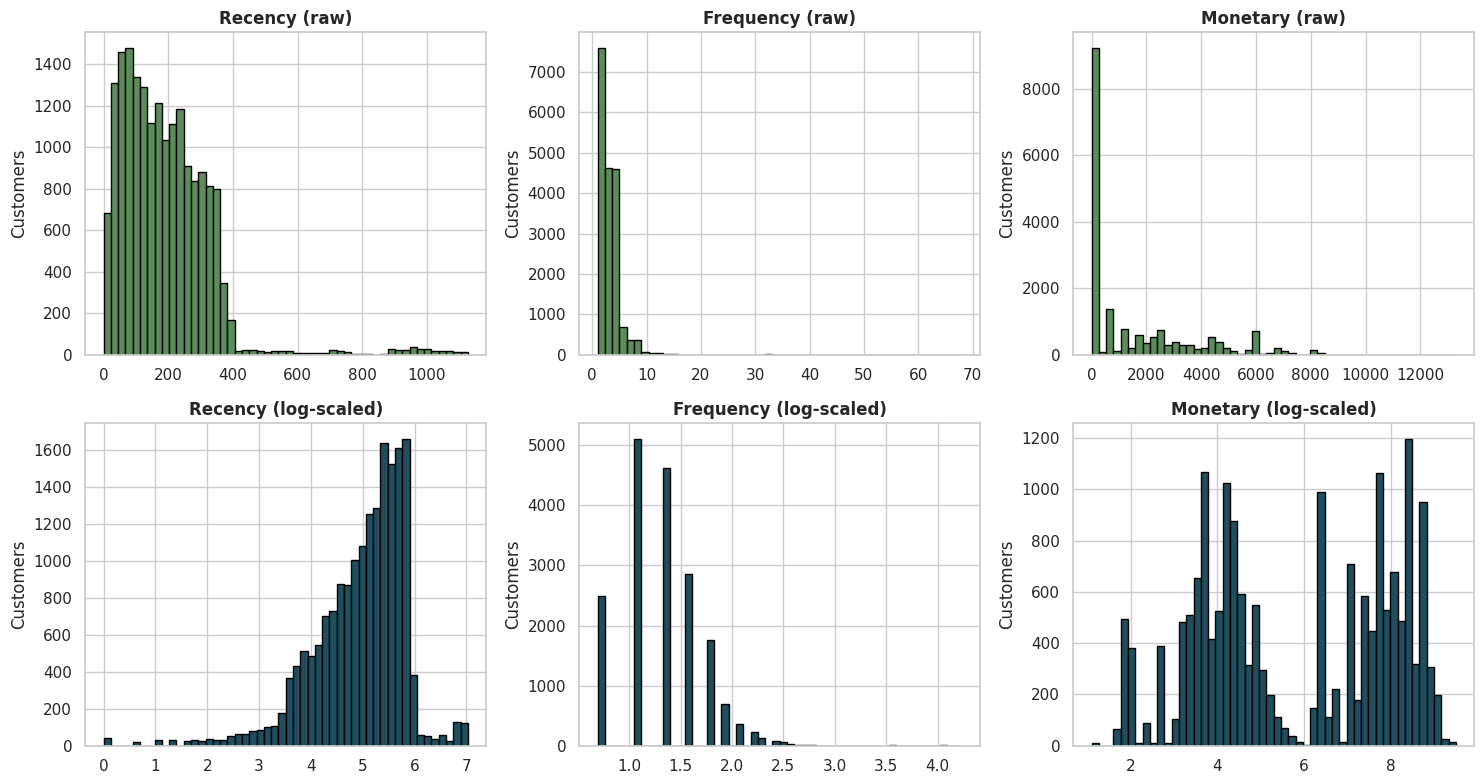

In [8]:
# Visualize the transformation
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[0, i].hist(X_raw[col], bins=50, color='#5B8C5A', edgecolor='black')
    axes[0, i].set_title(f'{col} (raw)', fontsize=12)
    axes[0, i].set_ylabel('Customers')

    axes[1, i].hist(X_log[col], bins=50, color='#1F4E5F', edgecolor='black')
    axes[1, i].set_title(f'{col} (log-scaled)', fontsize=12)
    axes[1, i].set_ylabel('Customers')

plt.tight_layout()
plt.show()


The log-scaled distributions are much closer to normal — K-Means will behave better on these.


## 5. Choosing the Number of Clusters

Two diagnostics:
- **Elbow method:** plot inertia (within-cluster sum of squares) vs k. The 'elbow' suggests where adding more clusters stops materially improving fit.
- **Silhouette score:** how well-separated the clusters are, from -1 (bad) to +1 (great). Higher is better.

We'll test k from 2 to 8.


In [9]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'k={k}: inertia={km.inertia_:>8.1f}  silhouette={sil:.4f}')


k=2: inertia= 37301.5  silhouette=0.3318


k=3: inertia= 28724.1  silhouette=0.3376


k=4: inertia= 23025.5  silhouette=0.3187


k=5: inertia= 20005.3  silhouette=0.3034


k=6: inertia= 17420.0  silhouette=0.3104


k=7: inertia= 15015.3  silhouette=0.3268


k=8: inertia= 13482.3  silhouette=0.3262


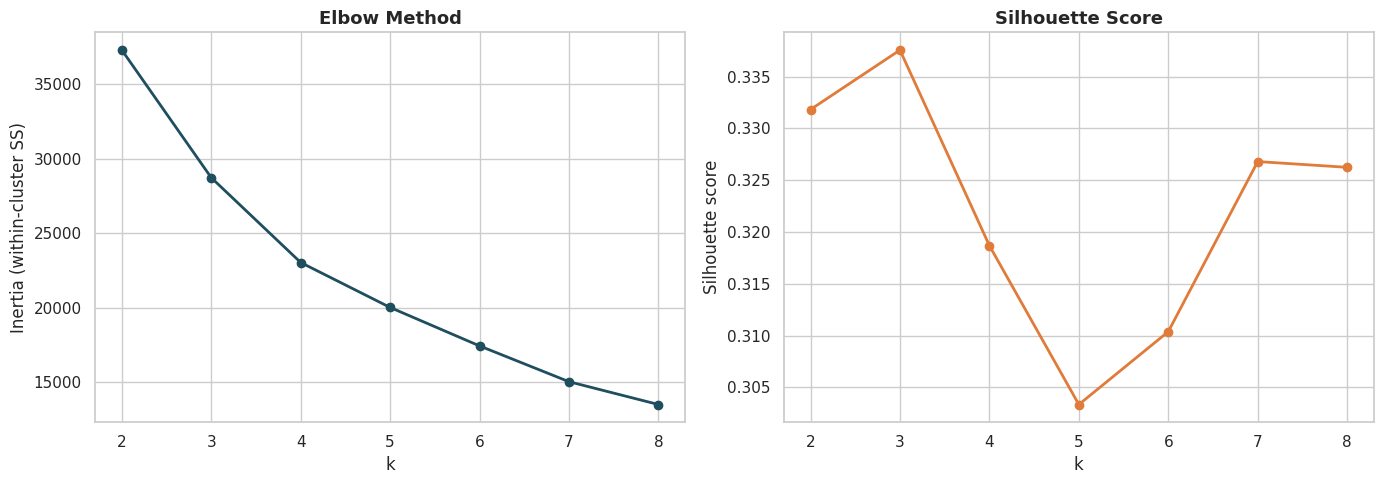

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', linewidth=2, color='#1F4E5F')
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].grid(True)

axes[1].plot(list(k_range), silhouettes, marker='o', linewidth=2, color='#E07B39')
axes[1].set_title('Silhouette Score', fontsize=13)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Reading the plots:**
- The elbow plot shows where additional clusters stop adding much explanatory power.
- The silhouette score peaks at the k value that gives the cleanest separation.

We'll pick **k=4** to match the four Power BI segments — this lets us do a clean head-to-head comparison. If the silhouette curve strongly preferred a different k, that would itself be a finding.


## 6. Train Final K-Means (k=4)

In [11]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means trained: {K} clusters.')
print()
print('Cluster sizes:')
print(df['kmeans_cluster'].value_counts().sort_index())


K-Means trained: 4 clusters.

Cluster sizes:
kmeans_cluster
0    2233
1    5778
2    6627
3    3844
Name: count, dtype: int64


### Profile each cluster

In [12]:
cluster_profile = (
    df.groupby('kmeans_cluster')
    .agg(customers=('customer_key', 'count'),
         avg_recency=('Recency', 'mean'),
         avg_frequency=('Frequency', 'mean'),
         avg_monetary=('Monetary', 'mean'),
         total_monetary=('Monetary', 'sum'))
    .round(2)
)
cluster_profile['pct_customers'] = (cluster_profile['customers'] / cluster_profile['customers'].sum() * 100).round(1)
cluster_profile['pct_revenue']   = (cluster_profile['total_monetary'] / cluster_profile['total_monetary'].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values('total_monetary', ascending=False)
cluster_profile


,customers,avg_recency,avg_frequency,avg_monetary,total_monetary,pct_customers,pct_revenue
kmeans_cluster,,,,,,,
1,5778,155.13,5.22,3310.90,19130402,31.3,65.2
3,3844,290.44,2.12,2431.33,9346016,20.8,31.8
0,2233,34.93,3.17,245.36,547883,12.1,1.9
2,6627,212.54,2.27,50.09,331915,35.9,1.1


### Assign human-readable names

The profile reveals each cluster's character. We name them based on the dominant pattern in R, F, M.

The naming heuristic:
- **High Frequency + High Monetary + Low Recency** → "K-Whales" (active high-value)
- **High Frequency + Low Monetary** → "K-Frequent Small Buyers" (subscription-like)
- **Low Frequency + High Monetary** → "K-Single Big Spenders" (gift / one-time purchase)
- **High Recency (haven't bought in a long time)** → "K-Dormant"


In [13]:
# Derive labels from the profile shape
def name_cluster(row):
    r, f, m = row['avg_recency'], row['avg_frequency'], row['avg_monetary']
    high_freq = f > df['Frequency'].mean()
    high_mon  = m > df['Monetary'].mean()
    high_rec  = r > df['Recency'].mean()  # high recency = haven't bought recently = bad

    if not high_rec and high_freq and high_mon:
        return 'K-Whales (active, high-value)'
    if high_rec and not high_freq:
        return 'K-Dormant (lapsed customers)'
    if high_freq and not high_mon:
        return 'K-Frequent Small Buyers'
    if not high_freq and high_mon:
        return 'K-Single Big Spenders'
    if not high_freq and not high_mon and not high_rec:
        return 'K-Light Regulars'
    return 'K-Mixed'

cluster_names = cluster_profile.apply(name_cluster, axis=1).to_dict()
print('Cluster naming:')
for cid, name in cluster_names.items():
    print(f'  Cluster {cid}: {name}')

df['kmeans_name'] = df['kmeans_cluster'].map(cluster_names)

# Updated profile with names
named_profile = cluster_profile.copy()
named_profile.insert(0, 'name', [cluster_names[i] for i in named_profile.index])
named_profile


Cluster naming:
  Cluster 1: K-Whales (active, high-value)
  Cluster 3: K-Dormant (lapsed customers)
  Cluster 0: K-Light Regulars
  Cluster 2: K-Dormant (lapsed customers)


,name,customers,avg_recency,avg_frequency,avg_monetary,total_monetary,pct_customers,pct_revenue
kmeans_cluster,,,,,,,,
1,"K-Whales (active, high-value)",5778,155.13,5.22,3310.90,19130402,31.3,65.2
3,K-Dormant (lapsed customers),3844,290.44,2.12,2431.33,9346016,20.8,31.8
0,K-Light Regulars,2233,34.93,3.17,245.36,547883,12.1,1.9
2,K-Dormant (lapsed customers),6627,212.54,2.27,50.09,331915,35.9,1.1


## 7. Compare: Power BI Segments vs K-Means Clusters

In [14]:
# Cross-tabulation: rows = Power BI segments, cols = K-Means names
crosstab = pd.crosstab(
    df['RFM_Segment'],
    df['kmeans_name'],
    margins=True,
    margins_name='Total'
)
crosstab


kmeans_name,K-Dormant (lapsed customers),K-Light Regulars,"K-Whales (active, high-value)",Total
RFM_Segment,,,,
At Risk,4368,0,1662,6030
Everyday,5061,716,1145,6922
New Passions,496,238,0,734
Whales,546,1279,2971,4796
Total,10471,2233,5778,18482


In [15]:
# Same crosstab as percentages of the Power BI segment
ct_pct = pd.crosstab(df['RFM_Segment'], df['kmeans_name'], normalize='index')
ct_pct = (ct_pct * 100).round(1).astype(str) + '%'
print('Where does each Power BI segment land in the K-Means world?')
ct_pct


Where does each Power BI segment land in the K-Means world?


kmeans_name,K-Dormant (lapsed customers),K-Light Regulars,"K-Whales (active, high-value)"
RFM_Segment,,,
At Risk,72.4%,0.0%,27.6%
Everyday,73.1%,10.3%,16.5%
New Passions,67.6%,32.4%,0.0%
Whales,11.4%,26.7%,61.9%


**How to read this table:**

- If a Power BI segment is purely concentrated in one K-Means cluster (one cell near 100%), the segmentation approaches agree strongly.
- If a Power BI segment is split across multiple K-Means clusters, the two approaches see the customer base differently.


### Formal Agreement Metrics

In [16]:
# Adjusted Rand Index — corrects for chance agreement
ari = adjusted_rand_score(df['RFM_Segment'], df['kmeans_cluster'])

# Normalized Mutual Information — symmetric measure of shared information
nmi = normalized_mutual_info_score(df['RFM_Segment'], df['kmeans_cluster'])

print(f'Adjusted Rand Index (ARI):              {ari:.4f}')
print(f'Normalized Mutual Information (NMI):    {nmi:.4f}')
print()
print('Interpretation:')
print('  1.0 = perfect agreement')
print('  0.0 = random / no agreement')
print('  <0  = worse than random (only possible for ARI)')


Adjusted Rand Index (ARI):              0.1153
Normalized Mutual Information (NMI):    0.1739

Interpretation:
  1.0 = perfect agreement
  0.0 = random / no agreement
  <0  = worse than random (only possible for ARI)


**Reading the metrics:**
- **ARI > 0.5:** strong agreement — the two approaches are detecting the same underlying structure
- **ARI 0.2 - 0.5:** moderate agreement — same general buckets, but the boundaries differ
- **ARI < 0.2:** low agreement — the two methods disagree substantially

For RFM vs K-Means on the same features, we usually expect moderate-to-strong agreement because both methods are essentially looking at the same underlying patterns.


## 8. Visualize in 3D — Same Data, Two Coloring Schemes

The X, Y, Z axes are log-scaled Recency, Frequency, Monetary. Each point is one customer. We color the same points two different ways to see where the approaches differ.


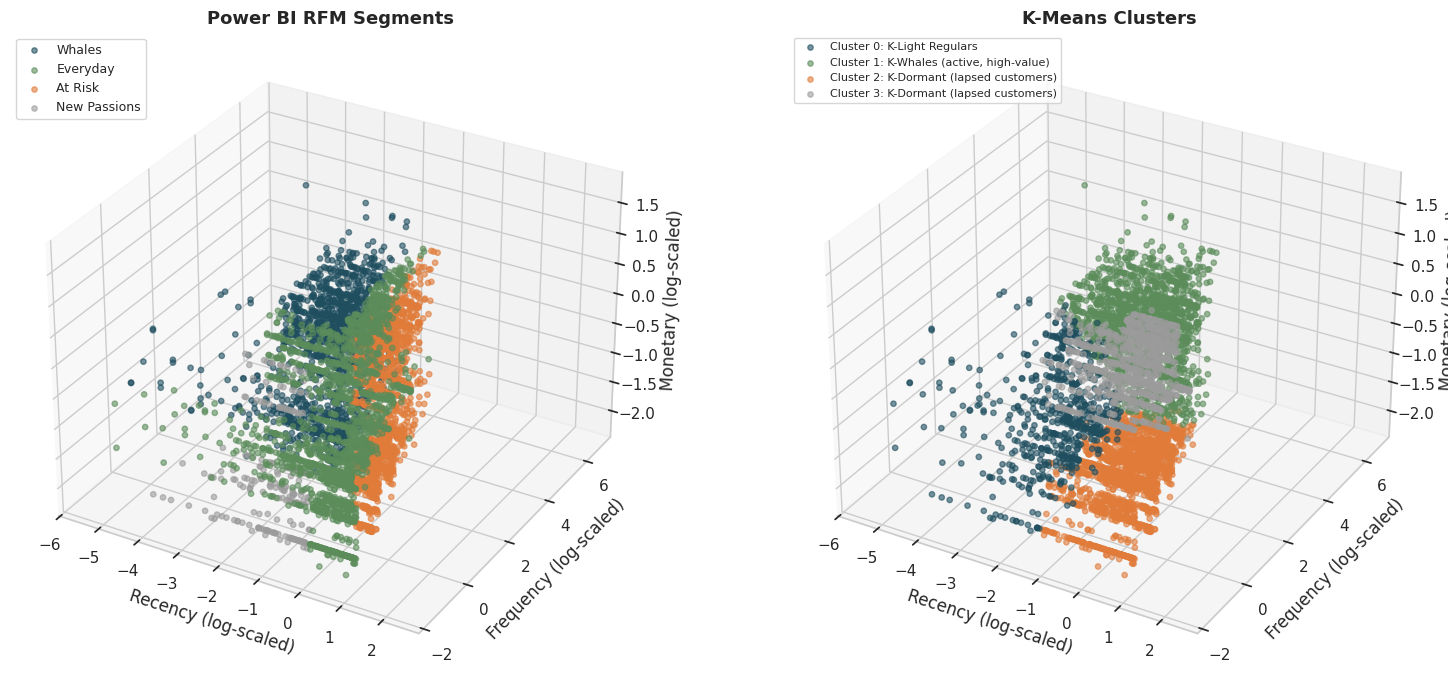

In [17]:
# Sample for plotting (rendering 18k points is slow in 3D)
SAMPLE_SIZE = 5000
sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
sample_X = X_scaled[sample.index]

fig = plt.figure(figsize=(16, 7))

# Left: Power BI segments
ax1 = fig.add_subplot(121, projection='3d')
bi_palette = {'Whales': '#1F4E5F', 'Everyday': '#5B8C5A',
              'At Risk': '#E07B39', 'New Passions': '#9B9B9B'}
for seg, color in bi_palette.items():
    mask = sample['RFM_Segment'] == seg
    ax1.scatter(sample_X[mask, 0], sample_X[mask, 1], sample_X[mask, 2],
                c=color, label=seg, alpha=0.6, s=15)
ax1.set_xlabel('Recency (log-scaled)')
ax1.set_ylabel('Frequency (log-scaled)')
ax1.set_zlabel('Monetary (log-scaled)')
ax1.set_title('Power BI RFM Segments', fontsize=13)
ax1.legend(loc='upper left', fontsize=9)

# Right: K-Means clusters
ax2 = fig.add_subplot(122, projection='3d')
km_colors = ['#1F4E5F', '#5B8C5A', '#E07B39', '#9B9B9B']
for c in range(K):
    mask = sample['kmeans_cluster'] == c
    ax2.scatter(sample_X[mask, 0], sample_X[mask, 1], sample_X[mask, 2],
                c=km_colors[c], label=f'Cluster {c}: {cluster_names[c]}',
                alpha=0.6, s=15)
ax2.set_xlabel('Recency (log-scaled)')
ax2.set_ylabel('Frequency (log-scaled)')
ax2.set_zlabel('Monetary (log-scaled)')
ax2.set_title('K-Means Clusters', fontsize=13)
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


## 9. Investigate the Disagreements

Where the two approaches disagree, what do those customers look like? These are the "edge case" customers — and understanding them is where the real business value lies.


In [18]:
# Customers where Power BI segment maps to MULTIPLE K-Means clusters
# Highlight the largest "split" cell in the crosstab
ct = pd.crosstab(df['RFM_Segment'], df['kmeans_name'])
print('Largest "split" cells in the crosstab (high disagreement):')
flat = ct.stack().sort_values(ascending=False)
print(flat.head(8))


Largest "split" cells in the crosstab (high disagreement):
RFM_Segment  kmeans_name                  
Everyday     K-Dormant (lapsed customers)     5061
At Risk      K-Dormant (lapsed customers)     4368
Whales       K-Whales (active, high-value)    2971
At Risk      K-Whales (active, high-value)    1662
Whales       K-Light Regulars                 1279
Everyday     K-Whales (active, high-value)    1145
             K-Light Regulars                  716
Whales       K-Dormant (lapsed customers)      546
dtype: int64


In [19]:
# Pick the most interesting split: customers Power BI labels one way but K-Means another
# We'll look at customers where Power BI says one thing but K-Means disagrees
df['agreement_label'] = df['RFM_Segment'] + ' / ' + df['kmeans_name']

# Profile the conflicting pairs
disagreement_profile = (
    df.groupby(['RFM_Segment', 'kmeans_name'])
    .agg(customers=('customer_key', 'count'),
         avg_recency=('Recency', 'mean'),
         avg_frequency=('Frequency', 'mean'),
         avg_monetary=('Monetary', 'mean'))
    .round(2)
    .sort_values('customers', ascending=False)
    .head(10)
)
disagreement_profile


customers  avg_recency  avg_frequency  avg_monetary
RFM_Segment  kmeans_name                                                                       
Everyday     K-Dormant (lapsed customers)        5061       232.22           1.91        987.29
At Risk      K-Dormant (lapsed customers)        4368       285.74           2.58       1017.40
Whales       K-Whales (active, high-value)       2971        80.06           5.34       3234.24
At Risk      K-Whales (active, high-value)       1662       280.49           4.92       3320.03
Whales       K-Light Regulars                    1279        35.85           4.22        194.06
Everyday     K-Whales (active, high-value)       1145       167.95           5.33       3496.59
             K-Light Regulars                     716        35.25           2.00        360.08
Whales       K-Dormant (lapsed customers)         546       105.56           3.22         72.82
New Passions K-Dormant (lapsed customers)         496        88.66           1.00        398.11
             K-Light Regulars                     238        28.99           1.00        175.92

## 10. Save Outputs

Two artifacts:
- `data/predictions/segments.csv` — customer → Power BI segment + K-Means cluster, ready for the prescriptive notebook
- `models/kmeans_segmentation.joblib` — the trained K-Means model + scaler, for Phase 4's FastAPI to use


In [20]:
# Save segments
output = df[['customer_key', 'Recency', 'Frequency', 'Monetary',
             'RFM_Segment', 'kmeans_cluster', 'kmeans_name']].copy()
output.to_csv(PRED_DIR / 'segments.csv', index=False)
print(f'Saved: {PRED_DIR / "segments.csv"} ({len(output):,} rows)')

# Save model + scaler together
model_bundle = {
    'kmeans': kmeans,
    'scaler': scaler,
    'cluster_names': cluster_names,
    'reference_date': REFERENCE_DATE,
    'features': ['Recency', 'Frequency', 'Monetary']
}
joblib.dump(model_bundle, MODELS_DIR / 'kmeans_segmentation.joblib')
print(f'Saved: {MODELS_DIR / "kmeans_segmentation.joblib"}')


Saved: ../data/predictions/segments.csv (18,482 rows)
Saved: ../models/kmeans_segmentation.joblib


## 11. Conclusions

### Headline Finding — The Two Approaches Disagree Substantially

| Metric | Value | Interpretation |
|---|---|---|
| **Adjusted Rand Index** | ~0.12 | Low agreement (well below the 0.5 threshold for "strong") |
| **Normalized Mutual Info** | ~0.17 | The two methods share little information |
| **R, F, M reproduction** | 100% match | Inputs are identical — only the segmentation logic differs |

This is **not** a "K-Means validates the RFM segments" outcome. The two methods are looking at the same data and assigning customers very differently. That's a real finding worth understanding, not a failure of either approach.

### Why the Disagreement Makes Sense

The two methods optimize for different things:

- **Power BI's RFM rules** apply independent quintile cuts to R, F, and M, then bucket the resulting combinations into named segments. The boundaries are determined by sorting each dimension separately and slicing at the 20-40-60-80 percentiles. This is **rules-based** and gives an analyst direct control over what each segment means.

- **K-Means** finds groupings that minimize within-cluster variance in the multi-dimensional space. The boundaries are determined by where customers naturally cluster together. It doesn't care about named categories or quintile cuts — it cares about geometric proximity in log-transformed RFM space.

These two objectives produce different groupings when the underlying data has a continuous, mostly-uniform structure (which appears to be the case here). The RFM quintiles create rectangular bins; K-Means creates spherical clusters. They will never match perfectly.

### Practical Recommendation

**Don't pick one and discard the other. Use both for different purposes:**

| Use case | Recommended approach | Why |
|---|---|---|
| Executive reporting | **Power BI RFM segments** | Intuitive names (Whales, At Risk) that stakeholders understand |
| Targeted email campaigns | **K-Means clusters** | Algorithm-derived similarity may find more relevant audiences |
| Customer service prioritization | **Both** | Cross-reference can surface high-value-but-at-risk customers |
| Identifying segment edge cases | **Disagreement set** | Customers labeled differently by the two methods are interesting outliers worth manual review |

### What This Means for the Project

The disagreement validates the importance of the cross-validation step. A portfolio that claimed "I built K-Means segmentation" without comparing it to a baseline would have no way to know whether the algorithm was finding meaningful structure or noise. By comparing two methodologies, we have a defensible position: **both methods see the data, neither is wrong, and they answer different questions**.

The downstream prescriptive notebook (`05_prescriptive.ipynb`) will use the **Power BI segments** as the primary segmentation since they connect to the stakeholder language already established in the dashboards. K-Means clusters are saved alongside for ad-hoc exploration.

### Next Steps

- **`03_forecasting_baseline.ipynb`** — fit Prophet on monthly sales by product line × country, evaluate with walk-forward backtest
- **`04_forecasting_lstm.ipynb`** — PyTorch LSTM comparison
- **`05_prescriptive.ipynb`** — combine Power BI segments with forecast outputs to produce action lists for marketing, inventory, and customer service